In [49]:
import networkx as nx
import numpy as np

def random_graph(num_files=100):
    # Create a directed acyclic graph
    G = nx.DiGraph()

    # Generate file sizes using a lognormal distribution
    file_sizes = np.random.lognormal(mean=5, sigma=1, size=num_files)
    # Add nodes with file size attributes
    for i in range(num_files):
        G.add_node(i, size=file_sizes[i])

    # Add edges to simulate dependencies, preferring smaller files to depend on larger ones
    for i in range(num_files):
        num_dependencies = np.random.poisson(2)  # Average number of dependencies
        if i > 0:
            # Sort potential dependencies by size in descending order (larger files first)
            potential_dependencies = sorted(range(i), key=lambda x: file_sizes[x], reverse=True)
            # Bias selection towards larger files by taking the top candidates
            dependencies = np.random.choice(
                potential_dependencies,
                size=min(num_dependencies, i),
                replace=False
            )
            for dep in dependencies:
                G.add_edge(dep, i)

    return G

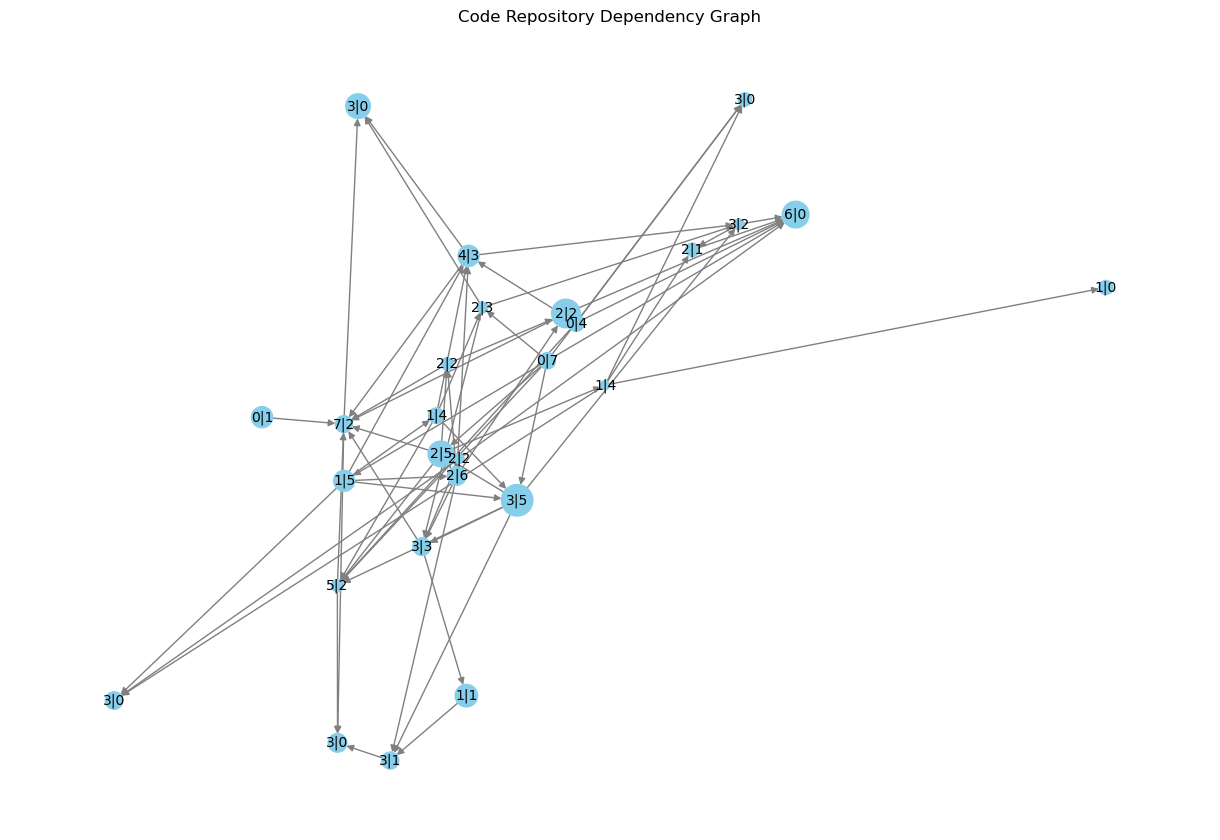

In [50]:
from matplotlib import pyplot as plt
def visualize_graph(G):
    # Extract node sizes based on the 'size' attribute
    node_sizes = [G.nodes[node]['size'] for node in G.nodes]
    
    # Generate positions for nodes using spring layout
    pos = nx.spring_layout(G)
    
    # Draw the graph
    plt.figure(figsize=(12, 8))
    labels = {node: f'{G.in_degree(node)}|{G.out_degree(node)}' for node in G.nodes}
    nx.draw(
        G,
        pos,
        with_labels=True,
        labels=labels,  # Use in-degree as labels
        node_size=node_sizes,  # Scale by file size
        node_color="skyblue",
        edge_color="gray",
        arrows=True,
        font_size=10,
    )
    
    # Show plot
    plt.title("Code Repository Dependency Graph")
    plt.show()

# Example usage with your generated graph
graph = random_graph(num_files=27)
visualize_graph(graph)